In [1]:
import os, sys, pickle, copy
import numpy as np
import matplotlib.pyplot as plt
import corner
import matplotlib.lines as mlines

In [2]:
def load_chain(path, param_names, mock_mean=[], mock_std=[], num_samples=[]):
    if os.path.exists(path):
        with open(path, 'rb') as handle:
            chain = pickle.load(handle)
        np.random.seed(42)
        for name, mean, std in zip(param_names, mock_mean, mock_std):
            if name not in chain:
                print(f"Warning: Key '{name}' not found in {path}. Generating mock data for this key.")
                chain[name] = np.random.normal(mean, std, len(next(iter(chain.values()))))
        return chain
    else:
        print(f"Warning: {path} not found. Generating mock data for visualization.")
        np.random.seed(42)
        chain = {}
        for name, mean, std in zip(param_names, mock_mean, mock_std):
            chain[name] = np.random.normal(mean, std, num_samples)
        return chain

param_names = [r'$\theta_{\rm E}$', r'$\gamma$', r'$q_{\rm m}$', r'$\phi_{\rm m}$']#, r'$\gamma_{\rm ext}$', r'$\phi_{\rm ext}$'

flat_chains = load_chain(
    's4_models/flat_chains.pickle',
    param_names,
)
flat_chains

{'$\\theta_{\\rm E}$': array([12.86461071, 12.86461071, 12.86461071, ..., 12.85688184,
        12.85688184, 12.85688184], shape=(63000,)),
 '$\\gamma$': array([1.42974757, 1.42974757, 1.42974757, ..., 1.43048853, 1.43048853,
        1.43048853], shape=(63000,)),
 '$q_{\\rm m}$': array([0.82380808, 0.82380808, 0.82380808, ..., 0.82825957, 0.82825957,
        0.82825957], shape=(63000,)),
 '$\\phi_{\\rm m}$': array([-81.59419543, -81.59419543, -81.59419543, ..., -81.83332489,
        -81.83332489, -81.83332489], shape=(63000,)),
 '$\\gamma_{\\rm ext}$': array([0.01907674, 0.01907674, 0.01907674, ..., 0.0202654 , 0.0202654 ,
        0.0202654 ], shape=(63000,)),
 '$\\phi_{\\rm ext}$': array([0.75816004, 0.75816004, 0.75816004, ..., 0.71380261, 0.71380261,
        0.71380261], shape=(63000,)),
 '$R_{\\rm s}$': array([0.27642601, 0.27642601, 0.27642601, ..., 0.27847291, 0.27847291,
        0.27847291], shape=(63000,)),
 '$q_{\\rm s}$': array([0.56824514, 0.56824514, 0.56824514, ..., 0.57165

In [3]:
shapelets_chains = load_chain(
    's4_models/flatshapelets_chains.pickle',
    param_names,
)
shapelets_chains

{'$\\theta_{\\rm E}$': array([12.82670375, 12.82826485, 12.82826485, ..., 12.81341837,
        12.81379921, 12.81782301], shape=(62700,)),
 '$\\gamma$': array([1.42237521, 1.42321526, 1.42321526, ..., 1.41347662, 1.41318436,
        1.41473762], shape=(62700,)),
 '$q_{\\rm m}$': array([0.83485085, 0.83451355, 0.83451355, ..., 0.83406577, 0.83361165,
        0.83425645], shape=(62700,)),
 '$\\phi_{\\rm m}$': array([-81.08422251, -81.06797253, -81.06797253, ..., -81.11580041,
        -81.12363894, -81.19958938], shape=(62700,)),
 '$\\gamma_{\\rm ext}$': array([0.01874076, 0.01880144, 0.01880144, ..., 0.01714037, 0.01702086,
        0.01750743], shape=(62700,)),
 '$\\phi_{\\rm ext}$': array([0.65554984, 0.6551734 , 0.6551734 , ..., 0.70526659, 0.71250573,
        0.70200343], shape=(62700,)),
 '$R_{\\rm s}$': array([0.28408893, 0.28504835, 0.28504835, ..., 0.29397268, 0.30055975,
        0.28901253], shape=(62700,)),
 '$q_{\\rm s}$': array([0.77130274, 0.77060176, 0.77060176, ..., 0.77118

In [4]:
iful_chains = load_chain(
    's4_models/iful_chains.pickle',
    param_names,
)
iful_chains

{'$\\theta_{\\rm E}$': array([12.8066941 , 12.81898766, 12.81760755, ..., 12.81235047,
        12.8146552 , 12.81610406], shape=(278296,)),
 '$\\gamma$': array([1.4117806 , 1.41407234, 1.41194577, ..., 1.41103637, 1.40973174,
        1.41066156], shape=(278296,)),
 '$q_{\\rm m}$': array([0.84739099, 0.84173024, 0.84278124, ..., 0.84441415, 0.84364817,
        0.84309931], shape=(278296,)),
 '$\\phi_{\\rm m}$': array([-81.71616111, -81.91168376, -81.45547214, ..., -81.63708159,
        -81.62874242, -81.58691501], shape=(278296,)),
 '$\\gamma_{\\rm ext}$': array([0.02046428, 0.02003049, 0.01896005, ..., 0.01950023, 0.01902895,
        0.01902443], shape=(278296,)),
 '$\\phi_{\\rm ext}$': array([0.60647464, 0.65839056, 0.63628236, ..., 0.63189023, 0.64473517,
        0.64402978], shape=(278296,)),
 '$R_{\\rm s}$': array([0.22807321, 0.23154603, 0.22935446, ..., 0.22851286, 0.22834142,
        0.22844515], shape=(278296,)),
 '$q_{\\rm s}$': array([0.69536529, 0.69567643, 0.69467007, ..., 

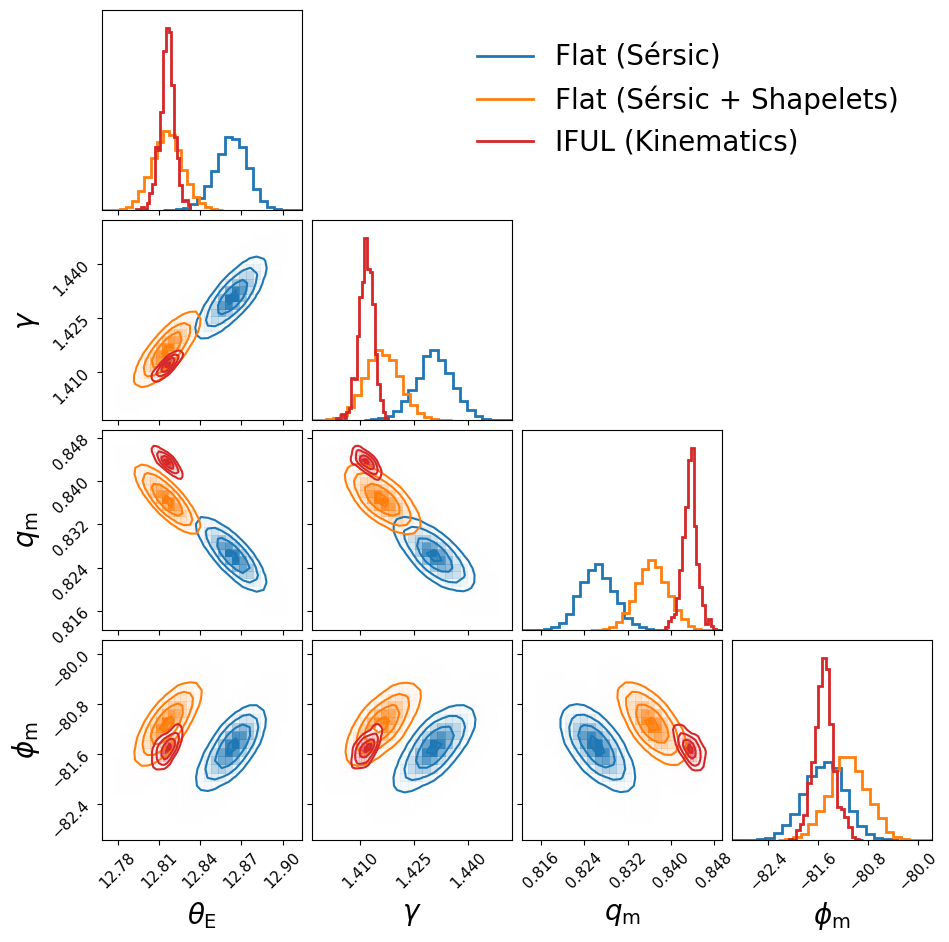

In [6]:
# Extract sample arrays for each model
flat_samples = np.column_stack([flat_chains[p] for p in param_names])
shapelets_samples = np.column_stack([shapelets_chains[p] for p in param_names])
iful_samples = np.column_stack([iful_chains[p] for p in param_names])

# Create the figure with the first dataset (flat_chains)
fig = corner.corner(
    flat_samples,
    labels=param_names,
    color="#1f77b4",          # Sleek Blue
    plot_datapoints=False,
    plot_density=True,
    fill_contours=False,
    show_titles=False,
    smooth=1,
    hist_kwargs={"linewidth": 2, "density": True},
    label_kwargs={"fontsize": 20}
)

# Overlay the second dataset (shapelets_chains)
corner.corner(
    shapelets_samples,
    fig=fig,
    color="#ff7f0e",          # Vibrant Orange
    plot_datapoints=False,
    plot_density=True,
    fill_contours=False,
    show_titles=False,
    smooth=1,
    hist_kwargs={"linewidth": 2, "density": True},
    label_kwargs={"fontsize": 20}
)

# Overlay the third dataset (iful_chains)
corner.corner(
    iful_samples,
    fig=fig,
    color="#d62728",          # Crimson Red
    plot_datapoints=False,
    plot_density=True,
    fill_contours=False,
    show_titles=False,
    smooth=1,
    hist_kwargs={"linewidth": 2, "density": True},
    label_kwargs={"fontsize": 20}
)

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=11)

# Add custom legend proxy artists
legend_labels = ["Flat (Sérsic)", "Flat (Sérsic + Shapelets)", "IFUL (Kinematics)"]
legend_colors = ["#1f77b4", "#ff7f0e", "#d62728"]
proxies = [mlines.Line2D([], [], color=color, linewidth=2, label=label) 
           for color, label in zip(legend_colors, legend_labels)]

# Place the legend in the upper-right corner of the figure where the empty space is
fig.legend(
    handles=proxies,
    bbox_to_anchor=(0.95, 0.95),
    loc="upper right",
    fontsize=20,
    frameon=True,
    facecolor='white',
    edgecolor='none'
)

plt.show()

______

In [20]:
param_names = [
    r"$\theta_{\rm E}$",
    r"$\gamma$",
    r"$\phi_{v}$",
    r"$A_{v}$",
    r"$R_{v}$",
    r"$v_{\rm c}$",
    r"$\sigma_{\rm c}$",
    r"$\log M_{\rm BH}$",]

iful_v_chains = load_chain(
    's4_models/iful_velocity_chains.pickle',
    param_names,
    [12.86, 1.43, 0.825, -81.7, 0.0195, 0.73],
    [0.005, 0.0005, 0.002, 0.1, 0.0006, 0.02],
    180000
)
iful_v_chains['$C_v - 1.432c$'] = iful_v_chains.pop('$v_{\\rm c}$') - 1.432*299792
iful_v_chains['$B_{v}$'] = iful_v_chains.pop("$R_{v}$")
iful_v_chains['$C_{\\sigma}$'] = iful_v_chains.pop("$\\sigma_{\\rm c}$")
iful_v_chains[r"$\log M_{\rm BH} / M_{\odot}$"] = iful_v_chains.pop(r"$\log M_{\rm BH}$")
iful_v_chains[r"$R_{v}$"] = iful_v_chains.pop('$B_{v}$')**-1
iful_v_chains['$A_{v}$'] = iful_v_chains.pop("$A_{v}$")*np.pi/2

param_names = [
    r"$\theta_{\rm E}$",
    r"$\gamma$",
    r"$\phi_{v}$",
    r"$A_{v}$",
    r"$R_{v}$",
    r"$C_v - 1.432c$",
    r"$C_{\sigma}$",
    r"$\log M_{\rm BH} / M_{\odot}$",]

iful_v_chains

{'$\\theta_{\\rm E}$': array([12.8066941 , 12.81898766, 12.81760755, ..., 12.81235047,
        12.8146552 , 12.81610406], shape=(278296,)),
 '$\\gamma$': array([1.4117806 , 1.41407234, 1.41194577, ..., 1.41103637, 1.40973174,
        1.41066156], shape=(278296,)),
 '$\\phi_{v}$': array([94.51865168, 94.14917812, 93.45787987, ..., 94.10396109,
        94.18636879, 93.10426081], shape=(278296,)),
 '$C_v - 1.432c$': array([61.96355068, 60.58565228, 63.40035018, ..., 61.36580371,
        61.09423448, 61.01904543], shape=(278296,)),
 '$C_{\\sigma}$': array([36.93367831, 37.26006861, 35.248045  , ..., 36.83568348,
        36.39466019, 37.0612597 ], shape=(278296,)),
 '$\\log M_{\\rm BH} / M_{\\odot}$': array([7.45243973, 7.38933321, 7.77834711, ..., 7.46144476, 7.43627959,
        7.35997273], shape=(278296,)),
 '$R_{v}$': array([0.23869324, 0.26037755, 0.27395748, ..., 0.22923074, 0.25074949,
        0.23496714], shape=(278296,)),
 '$A_{v}$': array([262.76730648, 274.77000645, 284.49149212,

In [24]:
inty = 4
print("$"+f"{np.median(iful_v_chains[param_names[inty]]):.3f}^"+"{+"+ 
      f"{np.percentile(iful_v_chains[param_names[inty]], 84.1) - np.median(iful_v_chains[param_names[inty]]):0.3f}" +"}_{-" +
      f"{np.median(iful_v_chains[param_names[inty]]) - np.percentile(iful_v_chains[param_names[inty]], 50-34.1):0.3f}" +"}$")

$0.241^{+0.017}_{-0.013}$


In [33]:
param_names_corner = [
    r"$\theta_{\rm E}$ ['']",
    r"$\gamma$",
    r"$\phi_{v}$ [$^{\rm o}$]",
    r"$A_{v}$ [km s$^{-1}$]",
    r"$R_{v}$ ['']",
    r"$C_v - 1.432c$ [km s$^{-1}$]",
    r"$C_{\sigma}$ [km s$^{-1}$]",
    r"$\log M_{\rm BH} / M_{\odot}$",]

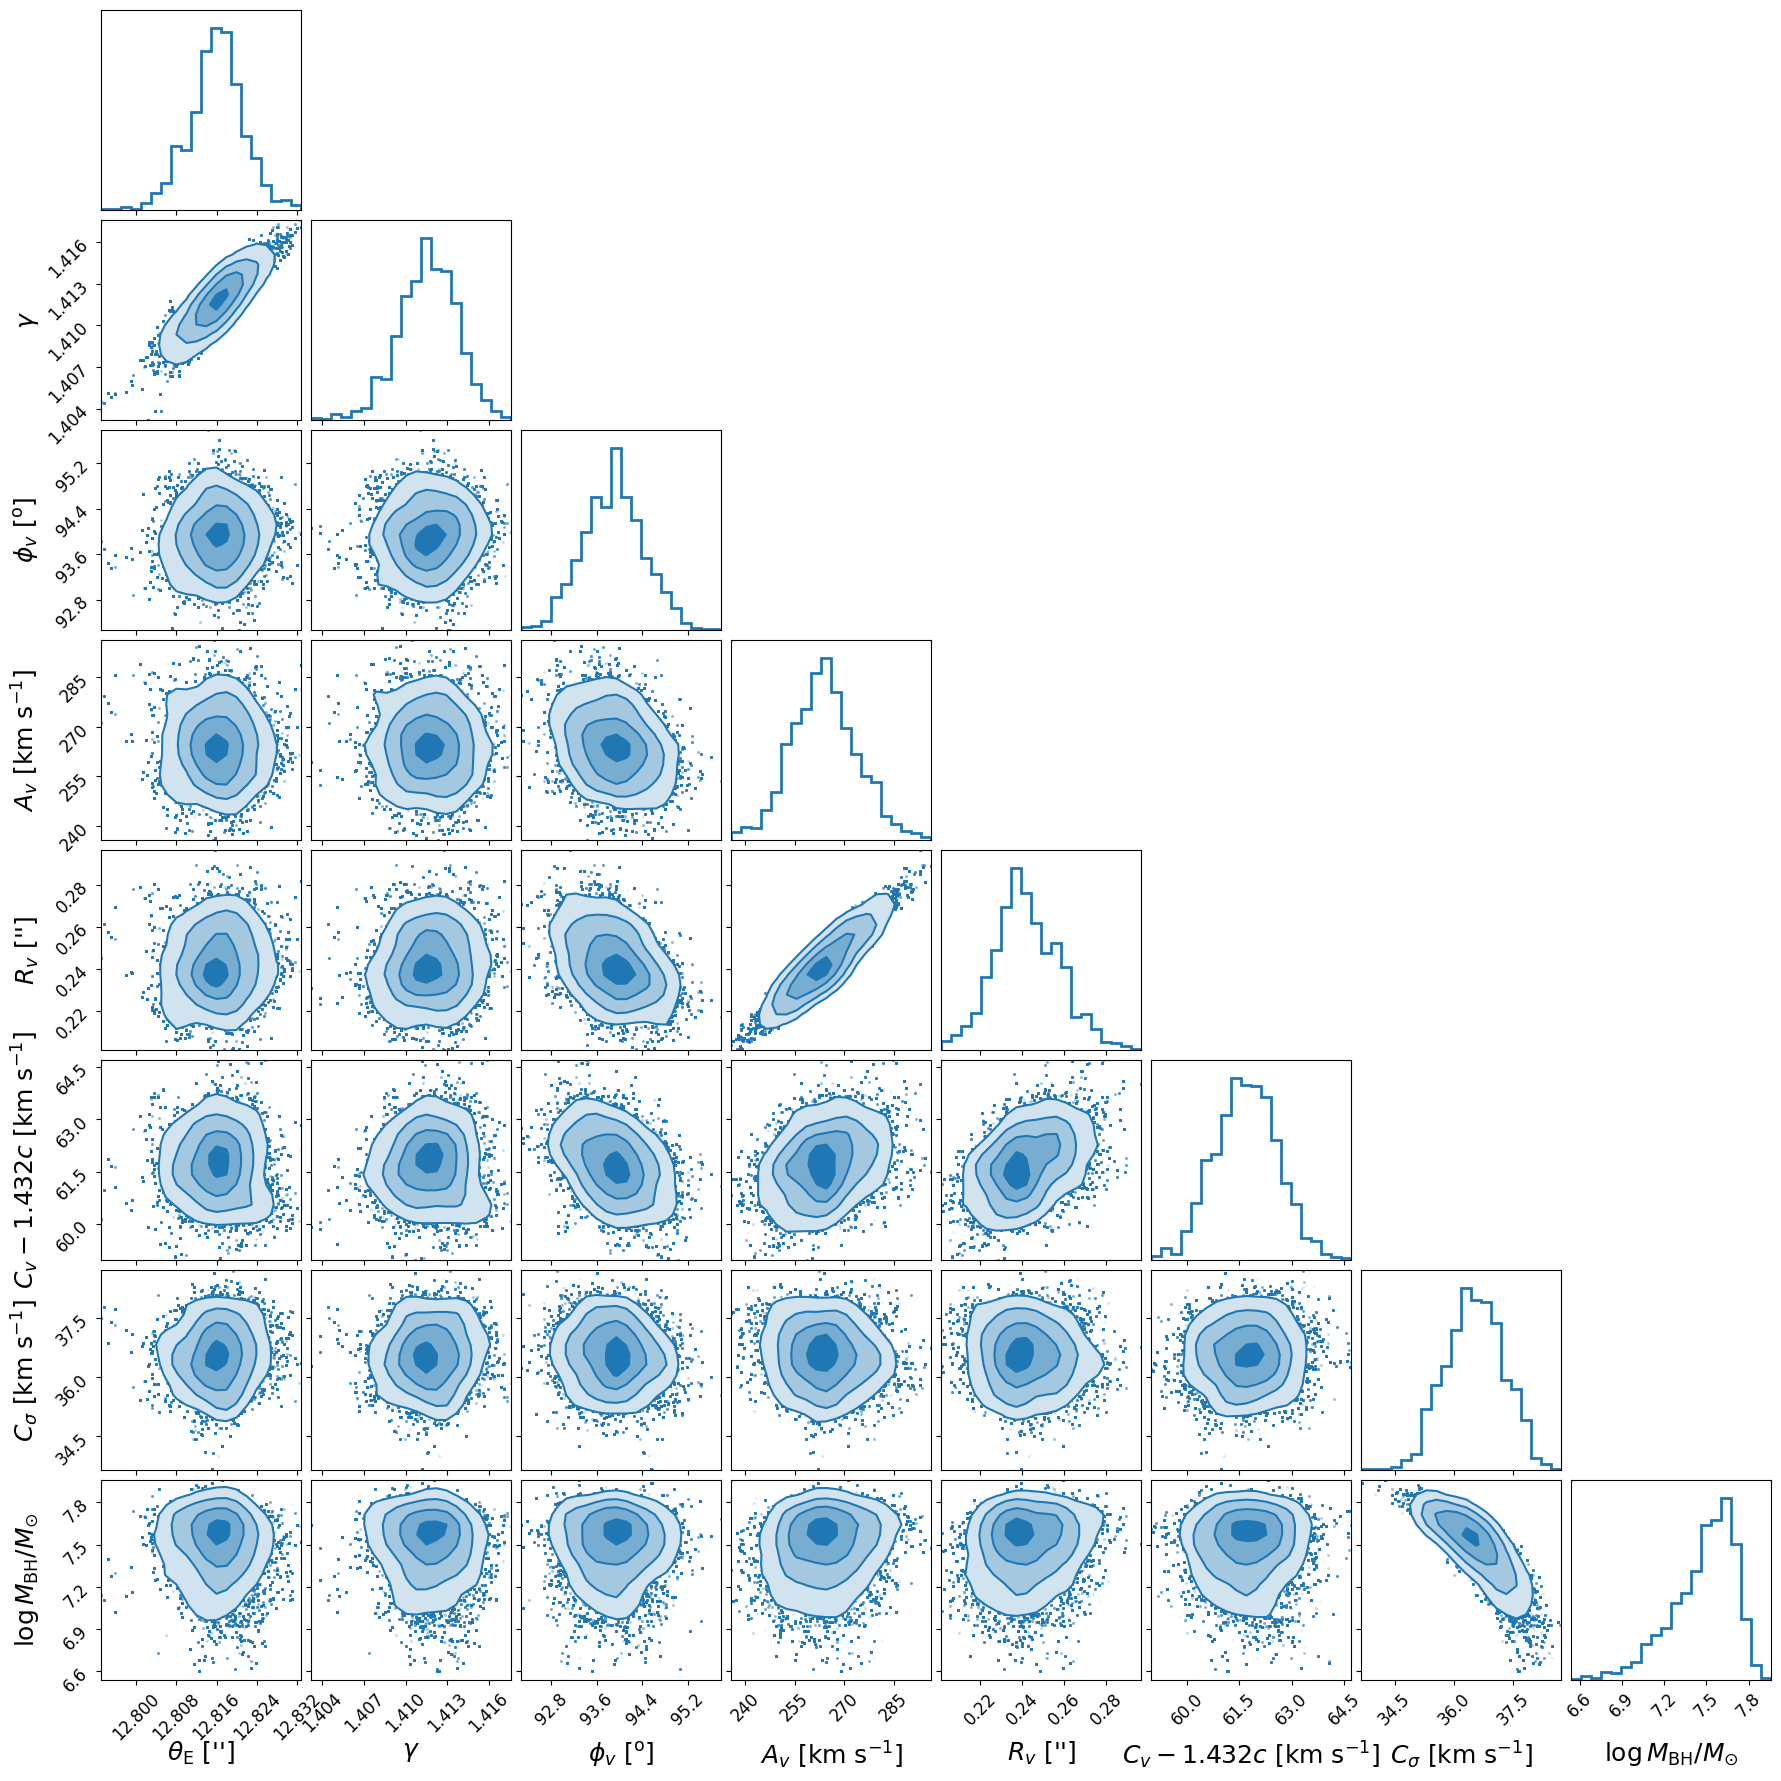

In [34]:
iful_v_samples = np.column_stack([iful_v_chains[p] for p in param_names])

fig = corner.corner(
    iful_v_samples,
    labels=param_names_corner,
    color="#1f77b4",
    plot_datapoints=True,
    plot_density=True,
    fill_contours=True,
    show_titles=False,
    smooth=1,
    hist_kwargs={"linewidth": 2},
    label_kwargs={"fontsize": 18}
)

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=12)

plt.show()